In [9]:
!pip install mglearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 5.4 MB/s eta 0:00:00


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import mglearn

In [12]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()


In [13]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

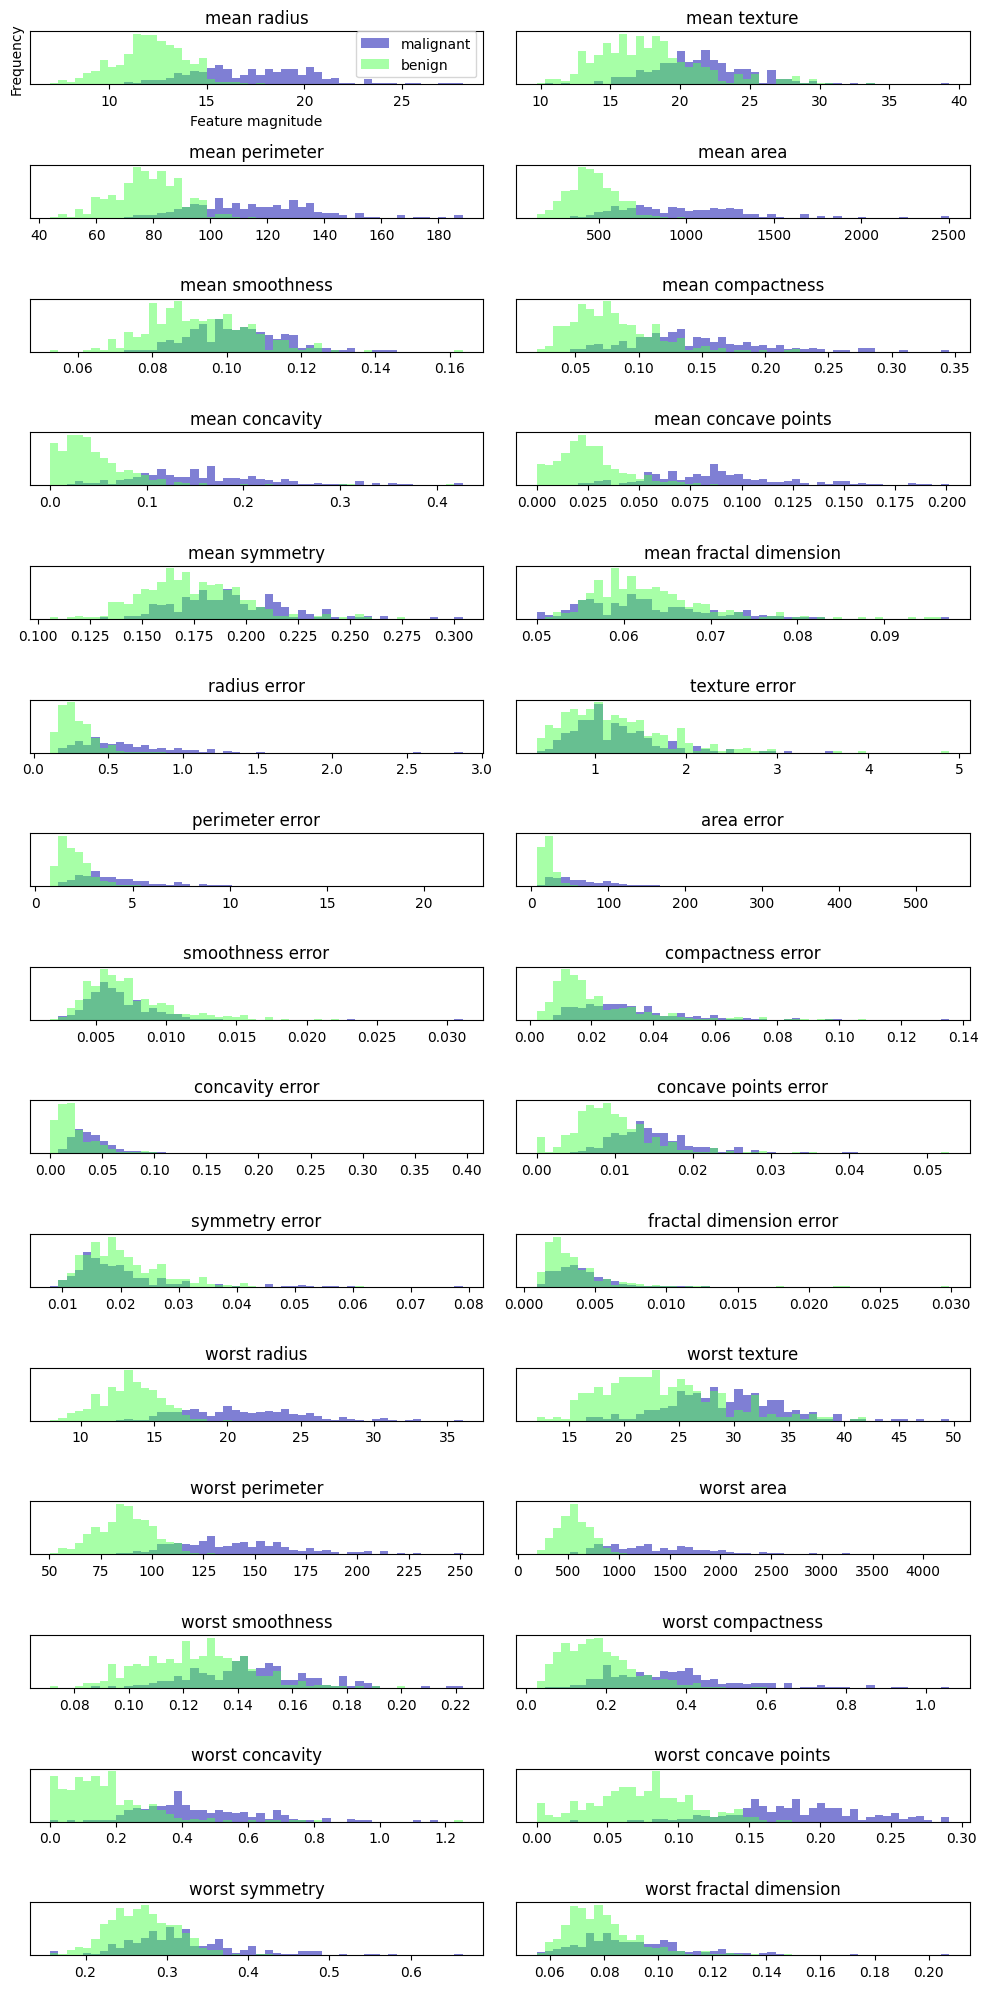

In [14]:
fig, axes = plt.subplots(15, 2, figsize=(10, 20))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]
ax = axes.ravel()

for i in range(30):
  _, bins = np.histogram(cancer.data[:, i], bins=50)
  ax[i].hist(malignant[:, i], bins=bins, color=mglearn.cm3(0), alpha=.5)
  ax[i].hist(benign[:, i], bins=bins, color=mglearn.cm3(2), alpha=.5)
  ax[i].set_title(cancer.feature_names[i])
  ax[i].set_yticks(())
ax[0].set_xlabel("Feature magnitude")
ax[0].set_ylabel("Frequency")
ax[0].legend(["malignant", "benign"], loc="best")
fig.tight_layout()

In [15]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance.

# The standard score of a sample x is calculated as:

# z = (x - u) / s

scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

In [16]:
from sklearn.decomposition import PCA
# keep the first two principal components of the data
pca = PCA(n_components=2)
# fit PCA model to breast cancer data
pca.fit(X_scaled)

 # transform data onto the first two principal components
X_pca = pca.transform(X_scaled)


Text(0, 0.5, 'Second principal component')

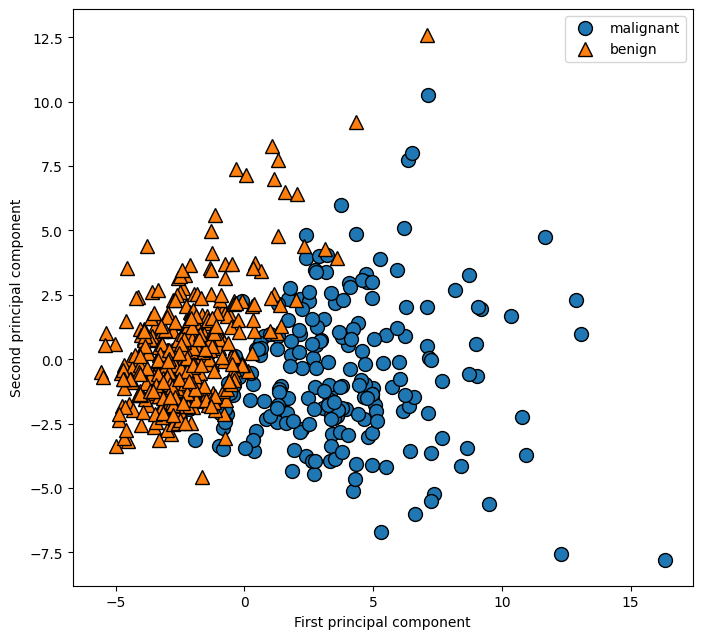

In [17]:

 plt.figure(figsize=(8, 8))
 mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], cancer.target)
 plt.legend(cancer.target_names, loc="best")
 plt.gca().set_aspect("equal")
 plt.xlabel("First principal component")
 plt.ylabel("Second principal component")

([<matplotlib.axis.XTick at 0x7b0b9fd2d510>,
 [Text(0, 1, 'mean radius'),
  Text(1, 1, 'mean texture'),
  Text(2, 1, 'mean perimeter'),
  Text(3, 1, 'mean area'),
  Text(4, 1, 'mean smoothness'),
  Text(5, 1, 'mean compactness'),
  Text(6, 1, 'mean concavity'),
  Text(7, 1, 'mean concave points'),
  Text(8, 1, 'mean symmetry'),
  Text(9, 1, 'mean fractal dimension'),
  Text(10, 1, 'radius error'),
  Text(11, 1, 'texture error'),
  Text(12, 1, 'perimeter error'),
  Text(13, 1, 'area error'),
  Text(14, 1, 'smoothness error'),
  Text(15, 1, 'compactness error'),
  Text(16, 1, 'concavity error'),
  Text(17, 1, 'concave points error'),
  Text(18, 1, 'symmetry error'),
  Text(19, 1, 'fractal dimension error'),
  Text(20, 1, 'worst radius'),
  Text(21, 1, 'worst texture'),
  Text(22, 1, 'worst perimeter'),
  Text(23, 1, 'worst area'),
  Text(24, 1, 'worst smoothness'),
  Text(25, 1, 'worst compactness'),
  Text(26, 1, 'worst concavity'),
  Text(27, 1, 'worst concave points'),
  Text(28, 1, '

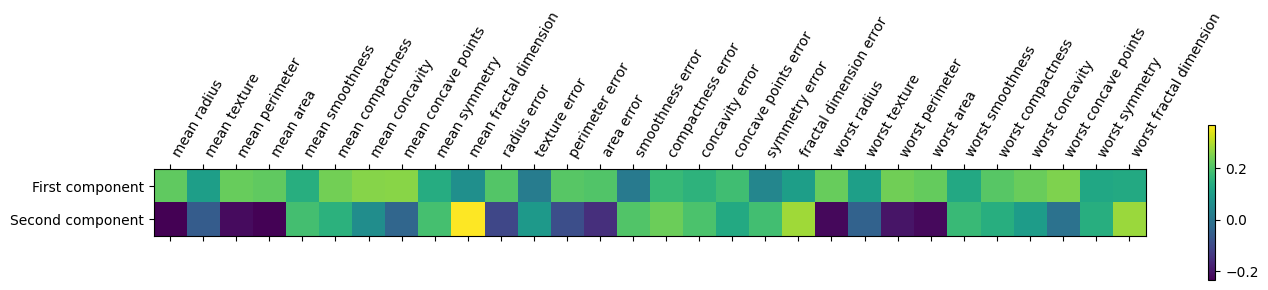

In [18]:
plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
           cancer.feature_names, rotation=60, ha='left')

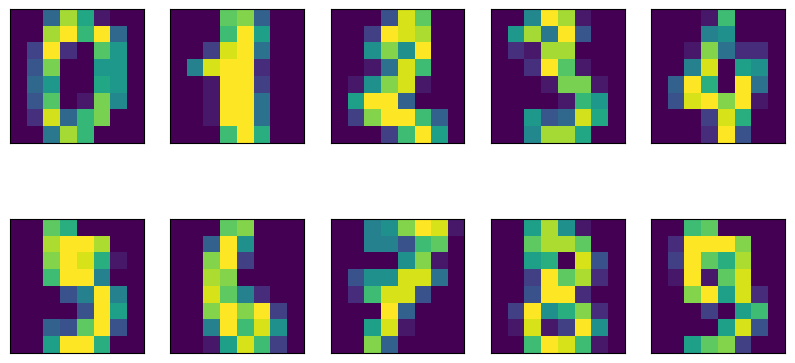

In [19]:
from sklearn.datasets import load_digits

digits = load_digits()
fig, axes = plt.subplots(2, 5, figsize=(10, 5),
                             subplot_kw={'xticks':(), 'yticks': ()})
for ax, img in zip(axes.ravel(), digits.images):
  ax.imshow(img)

Text(0, 0.5, 'Second principal component')

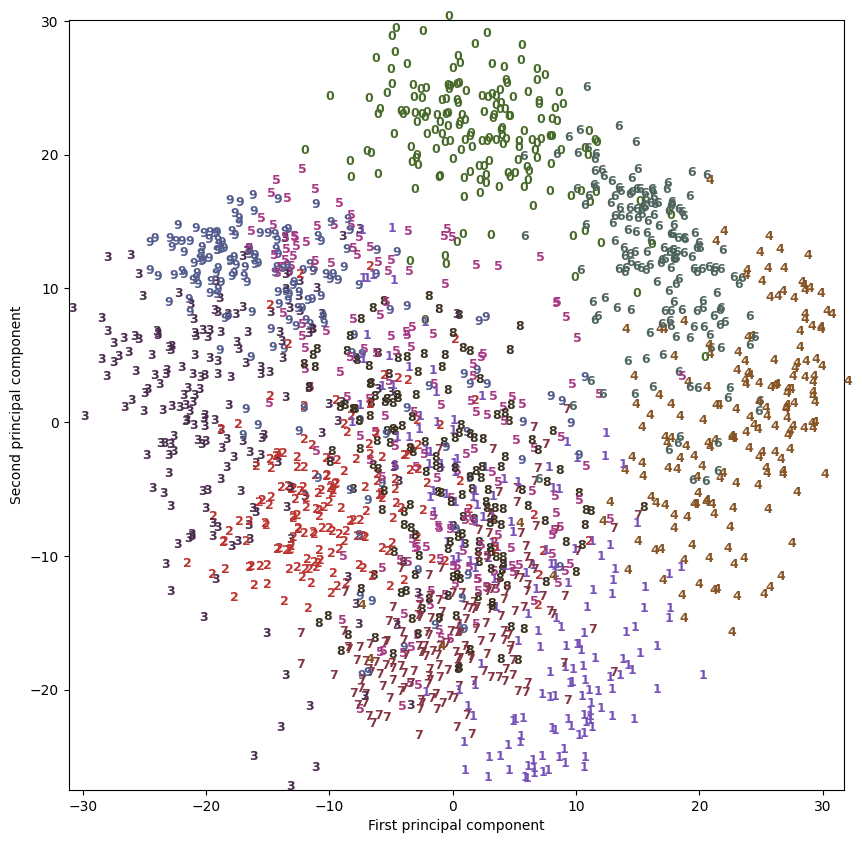

In [31]:
# build a PCA model
pca = PCA(n_components=10)
pca.fit(digits.data)
# transform the digits data onto the first two principal components
digits_pca = pca.transform(digits.data)
colors = ["#476A2A", "#7851B8", "#BD3430", "#4A2D4E", "#875525",
              "#A83683", "#4E655E", "#853541", "#3A3120", "#535D8E"]

plt.figure(figsize=(10, 10))

plt.xlim(digits_pca[:, 0].min(), digits_pca[:, 0].max())
plt.ylim(digits_pca[:, 1].min(), digits_pca[:, 1].max())

for i in range(len(digits.data)):
        # actually plot the digits as text instead of using scatter
        plt.text(digits_pca[i, 0], digits_pca[i, 1], str(digits.target[i]),
                 color = colors[digits.target[i]],
                 fontdict={'weight': 'bold', 'size': 9})
plt.xlabel("First principal component")
plt.ylabel("Second principal component")


In [29]:
from sklearn.manifold import TSNE
tsne = TSNE(random_state=42)
# use fit_transform instead of fit, as TSNE has no transform method
digits_tsne = tsne.fit_transform(digits.data)

In [30]:
plt.figure(figsize=(10, 10))
plt.xlim(digits_tsne[:, 0].min(), digits_tsne[:, 0].max() + 1)
plt.ylim(digits_tsne[:, 1].min(), digits_tsne[:, 1].max() + 1)

for i in range(len(digits.data)):
        # actually plot the digits as text instead of using scatter
        plt.text(digits_tsne[i, 0], digits_tsne[i, 1], str(digits.target[i]),
                 color = colors[digits.target[i]],
                 fontdict={'weight': 'bold', 'size': 9})
plt.xlabel("t-SNE feature 0")
plt.xlabel("t-SNE feature 1")

IndexError: index 2 is out of bounds for axis 1 with size 2

<Figure size 1000x1000 with 0 Axes>